In [1]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation
)

# ==============================
# PATHS (CHANGE ONLY THESE)
# ==============================
RAW_DATASET = "/kaggle/input/pldseg/PLD_3_Classes_256"
SEGMENTED_DATASET = "/kaggle/working/PLD_segmented"

SPLITS = ["Testing", "Training", "Validation"]
CLASSES = ["Early_Blight", "Healthy", "Late_Blight"]

IMG_SIZE = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(SEGMENTED_DATASET, exist_ok=True)


2026-02-02 10:44:14.575925: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770029054.772458      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770029054.827374      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770029055.296283      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770029055.296324      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770029055.296327      55 computation_placer.cc:177] computation placer alr

In [2]:
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"
)

segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"
).to(DEVICE)

segformer_model.eval()
print("SegFormer-B2 loaded")


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

SegFormer-B2 loaded


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

In [3]:
for split in SPLITS:
    for cls in CLASSES:
        input_dir = os.path.join(RAW_DATASET, split, cls)
        output_dir = os.path.join(SEGMENTED_DATASET, split, cls)
        os.makedirs(output_dir, exist_ok=True)

        for img_name in tqdm(
            os.listdir(input_dir),
            desc=f"Segmenting {split}/{cls}"
        ):
            img_path = os.path.join(input_dir, img_name)

            img_bgr = cv2.imread(img_path)
            if img_bgr is None:
                continue

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

            inputs = processor(images=img_resized, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = segformer_model(**inputs)

            logits = outputs.logits
            logits = F.interpolate(
                logits,
                size=img_resized.shape[:2],
                mode="bilinear",
                align_corners=False
            )

            pred_mask = logits.argmax(dim=1)[0].cpu().numpy()

            # Foreground mask
            foreground_mask = (pred_mask != 0).astype(np.uint8) * 255
            foreground_mask_3ch = cv2.cvtColor(
                foreground_mask, cv2.COLOR_GRAY2BGR
            )

            segmented = cv2.bitwise_and(
                img_resized, foreground_mask_3ch
            )

            save_path = os.path.join(output_dir, img_name)
            cv2.imwrite(
                save_path,
                cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR)
            )

print("PLD segmentation completed")


Segmenting Validation/Late_Blight: 100%|██████████| 151/151 [00:08<00:00, 18.04it/s]

PLD segmentation completed


In [5]:
!pip install -q timm albumentations


In [6]:
!pip install -q timm


In [4]:
# =====================================================
# 0. SEED (REPRODUCIBILITY)
# =====================================================
import random, os, torch, numpy as np
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =====================================================
# 1. IMPORTS
# =====================================================
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

# =====================================================
# 2. CONFIG
# =====================================================
DATA_DIR = "/kaggle/working/PLD_segmented"
SAVE_DIR = "/kaggle/working/saved_models"
XAI_DIR  = "/kaggle/working/xai_results"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(XAI_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-4
NUM_CLASSES = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["Early_Blight", "Late_Blight", "Healthy"]

MODELS = [
    "resnet",
    "mobilenetv3",
    "efficientnet_b0",
    "efficientnet_v2_s"
]

# =====================================================
# 3. TRANSFORMS
# =====================================================
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# =====================================================
# 4. DATA LOADERS
# =====================================================
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Training"), transform=train_tfms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "Validation"), transform=val_tfms)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "Testing"), transform=val_tfms)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, BATCH_SIZE, shuffle=False)

# =====================================================
# 5. MODEL FACTORY
# =====================================================
def get_model(name):
    if name == "resnet":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    elif name == "mobilenetv3":
        model = models.mobilenet_v3_large(
            weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)

    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

    elif name == "efficientnet_v2_s":
        model = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

    return model.to(DEVICE)

# =====================================================
# 6. TRAIN & EVAL
# =====================================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0,0,0
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1)==y).sum().item()
        total += y.size(0)
    return loss_sum/len(loader), correct/total

def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0,0,0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out,y).item()
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)
    return loss_sum/len(loader), correct/total

def get_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x,y in loader:
            out = model(x.to(DEVICE))
            y_true.extend(y.numpy())
            y_pred.extend(out.argmax(1).cpu().numpy())
    return np.array(y_true), np.array(y_pred)

# =====================================================
# 7. TRAIN ALL MODELS + SAVE
# =====================================================
results = {}
trained_models = {}

for name in MODELS:
    print(f"\nTraining {name.upper()}")
    model = get_model(name)
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        ta = train_one_epoch(model, train_loader, optimizer, criterion)[1]
        va = evaluate(model, val_loader, criterion)[1]
        print(f"Epoch {epoch+1:02d} | Train Acc {ta:.4f} | Val Acc {va:.4f}")

    test_acc = evaluate(model, test_loader, criterion)[1]
    results[name] = test_acc
    trained_models[name] = model

    torch.save(model.state_dict(), f"{SAVE_DIR}/{name}.pth")

# =====================================================
# 8. SELECT TOP MODEL
# =====================================================
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name.upper()}  |  Acc: {results[best_model_name]:.4f}")

# =====================================================
# 9. FAILURE CASES
# =====================================================
best_model.eval()
failures = []

with torch.no_grad():
    for idx,(x,y) in enumerate(test_ds):
        out = best_model(x.unsqueeze(0).to(DEVICE))
        pred = out.argmax(1).item()
        if pred != y:
            failures.append((x, y, pred))
        if len(failures) >= 5:
            break

print(f"Failure cases found: {len(failures)}")




Training RESNET
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 228MB/s]


Epoch 01 | Train Acc 0.9452 | Val Acc 0.9976
Epoch 02 | Train Acc 0.9862 | Val Acc 0.9904
Epoch 03 | Train Acc 0.9877 | Val Acc 1.0000
Epoch 04 | Train Acc 0.9874 | Val Acc 0.9976
Epoch 05 | Train Acc 0.9908 | Val Acc 1.0000
Epoch 06 | Train Acc 0.9920 | Val Acc 0.9976
Epoch 07 | Train Acc 0.9920 | Val Acc 0.9928
Epoch 08 | Train Acc 0.9929 | Val Acc 0.9976
Epoch 09 | Train Acc 0.9966 | Val Acc 0.9952
Epoch 10 | Train Acc 0.9954 | Val Acc 0.9904
Epoch 11 | Train Acc 0.9954 | Val Acc 0.9904
Epoch 12 | Train Acc 0.9985 | Val Acc 0.9976
Epoch 13 | Train Acc 0.9982 | Val Acc 0.9952
Epoch 14 | Train Acc 0.9938 | Val Acc 1.0000
Epoch 15 | Train Acc 0.9957 | Val Acc 0.9952
Epoch 16 | Train Acc 0.9911 | Val Acc 0.9904
Epoch 17 | Train Acc 0.9966 | Val Acc 0.9952
Epoch 18 | Train Acc 0.9889 | Val Acc 0.9832
Epoch 19 | Train Acc 0.9975 | Val Acc 0.9976
Epoch 20 | Train Acc 0.9982 | Val Acc 0.9952
Epoch 21 | Train Acc 0.9966 | Val Acc 0.9952
Epoch 22 | Train Acc 0.9975 | Val Acc 1.0000
Epoch 23 |

100%|██████████| 21.1M/21.1M [00:00<00:00, 174MB/s]


Epoch 01 | Train Acc 0.9065 | Val Acc 0.9784
Epoch 02 | Train Acc 0.9834 | Val Acc 0.9976
Epoch 03 | Train Acc 0.9905 | Val Acc 0.9928
Epoch 04 | Train Acc 0.9951 | Val Acc 0.9880
Epoch 05 | Train Acc 0.9935 | Val Acc 0.9880
Epoch 06 | Train Acc 0.9908 | Val Acc 0.9904
Epoch 07 | Train Acc 0.9963 | Val Acc 0.9928
Epoch 08 | Train Acc 0.9982 | Val Acc 0.9904
Epoch 09 | Train Acc 0.9969 | Val Acc 0.9856
Epoch 10 | Train Acc 0.9988 | Val Acc 0.9904
Epoch 11 | Train Acc 0.9972 | Val Acc 0.9856
Epoch 12 | Train Acc 0.9969 | Val Acc 0.9904
Epoch 13 | Train Acc 0.9988 | Val Acc 0.9880
Epoch 14 | Train Acc 0.9994 | Val Acc 0.9880
Epoch 15 | Train Acc 0.9985 | Val Acc 0.9928
Epoch 16 | Train Acc 0.9997 | Val Acc 0.9928
Epoch 17 | Train Acc 1.0000 | Val Acc 0.9904
Epoch 18 | Train Acc 0.9969 | Val Acc 0.9928
Epoch 19 | Train Acc 0.9978 | Val Acc 0.9928
Epoch 20 | Train Acc 0.9994 | Val Acc 0.9880
Epoch 21 | Train Acc 0.9991 | Val Acc 0.9928
Epoch 22 | Train Acc 0.9988 | Val Acc 0.9712
Epoch 23 |

100%|██████████| 20.5M/20.5M [00:00<00:00, 167MB/s]


Epoch 01 | Train Acc 0.8982 | Val Acc 0.9856
Epoch 02 | Train Acc 0.9800 | Val Acc 0.9904
Epoch 03 | Train Acc 0.9902 | Val Acc 0.9976
Epoch 04 | Train Acc 0.9902 | Val Acc 0.9976
Epoch 05 | Train Acc 0.9942 | Val Acc 0.9952
Epoch 06 | Train Acc 0.9926 | Val Acc 0.9880
Epoch 07 | Train Acc 0.9938 | Val Acc 0.9880
Epoch 08 | Train Acc 0.9972 | Val Acc 0.9904
Epoch 09 | Train Acc 0.9957 | Val Acc 0.9952
Epoch 10 | Train Acc 0.9963 | Val Acc 0.9904
Epoch 11 | Train Acc 0.9978 | Val Acc 0.9928
Epoch 12 | Train Acc 0.9969 | Val Acc 0.9952
Epoch 13 | Train Acc 0.9975 | Val Acc 0.9904
Epoch 14 | Train Acc 0.9991 | Val Acc 0.9952
Epoch 15 | Train Acc 0.9994 | Val Acc 0.9928
Epoch 16 | Train Acc 1.0000 | Val Acc 0.9976
Epoch 17 | Train Acc 0.9978 | Val Acc 1.0000
Epoch 18 | Train Acc 0.9978 | Val Acc 0.9928
Epoch 19 | Train Acc 0.9985 | Val Acc 0.9976
Epoch 20 | Train Acc 0.9994 | Val Acc 0.9952
Epoch 21 | Train Acc 0.9994 | Val Acc 0.9928
Epoch 22 | Train Acc 0.9991 | Val Acc 0.9976
Epoch 23 |

100%|██████████| 82.7M/82.7M [00:00<00:00, 180MB/s]


Epoch 01 | Train Acc 0.9163 | Val Acc 0.9928
Epoch 02 | Train Acc 0.9855 | Val Acc 0.9952
Epoch 03 | Train Acc 0.9914 | Val Acc 0.9928
Epoch 04 | Train Acc 0.9920 | Val Acc 0.9952
Epoch 05 | Train Acc 0.9935 | Val Acc 0.9952
Epoch 06 | Train Acc 0.9954 | Val Acc 0.9976
Epoch 07 | Train Acc 0.9982 | Val Acc 0.9952
Epoch 08 | Train Acc 0.9960 | Val Acc 0.9952
Epoch 09 | Train Acc 0.9975 | Val Acc 0.9928
Epoch 10 | Train Acc 0.9978 | Val Acc 0.9976
Epoch 11 | Train Acc 0.9985 | Val Acc 0.9952
Epoch 12 | Train Acc 0.9985 | Val Acc 0.9904
Epoch 13 | Train Acc 0.9957 | Val Acc 0.9976
Epoch 14 | Train Acc 0.9972 | Val Acc 0.9976
Epoch 15 | Train Acc 0.9975 | Val Acc 0.9976
Epoch 16 | Train Acc 0.9982 | Val Acc 0.9928
Epoch 17 | Train Acc 0.9972 | Val Acc 1.0000
Epoch 18 | Train Acc 0.9994 | Val Acc 0.9952
Epoch 19 | Train Acc 1.0000 | Val Acc 1.0000
Epoch 20 | Train Acc 0.9997 | Val Acc 0.9976
Epoch 21 | Train Acc 1.0000 | Val Acc 1.0000
Epoch 22 | Train Acc 0.9988 | Val Acc 0.9976
Epoch 23 |


================ RESNET =================

Classification Report:
              precision    recall  f1-score   support

Early_Blight     0.9939    1.0000    0.9969       162
 Late_Blight     0.9806    0.9902    0.9854       102
     Healthy     0.9928    0.9787    0.9857       141

    accuracy                         0.9901       405
   macro avg     0.9891    0.9896    0.9893       405
weighted avg     0.9902    0.9901    0.9901       405



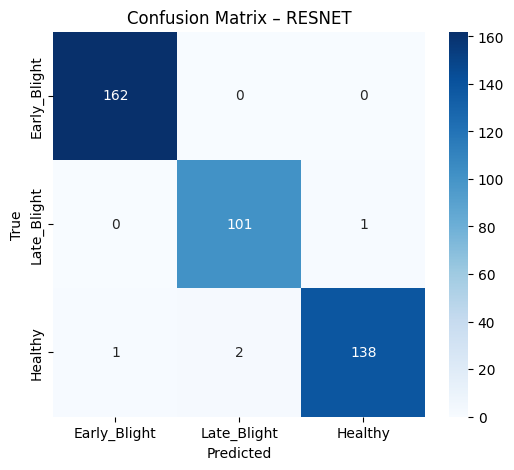


================ MOBILENETV3 =================

Classification Report:
              precision    recall  f1-score   support

Early_Blight     0.9937    0.9753    0.9844       162
 Late_Blight     0.9524    0.9804    0.9662       102
     Healthy     0.9929    0.9929    0.9929       141

    accuracy                         0.9827       405
   macro avg     0.9797    0.9829    0.9812       405
weighted avg     0.9830    0.9827    0.9828       405



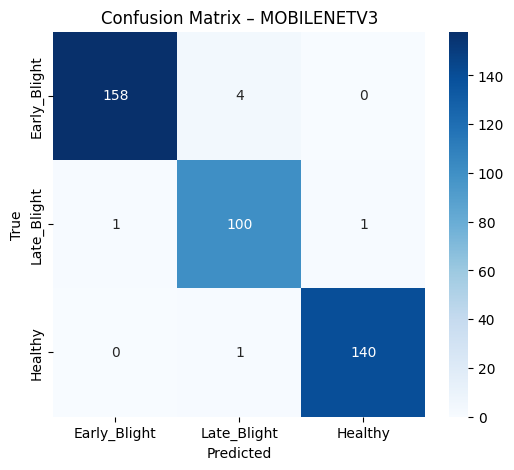


================ EFFICIENTNET_B0 =================

Classification Report:
              precision    recall  f1-score   support

Early_Blight     0.9938    0.9938    0.9938       162
 Late_Blight     0.9808    1.0000    0.9903       102
     Healthy     1.0000    0.9858    0.9929       141

    accuracy                         0.9926       405
   macro avg     0.9915    0.9932    0.9923       405
weighted avg     0.9927    0.9926    0.9926       405



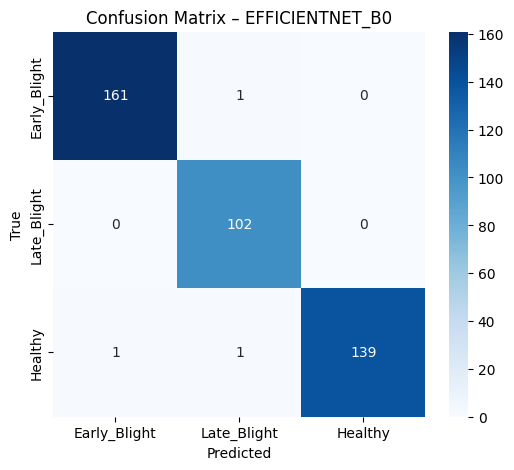


================ EFFICIENTNET_V2_S =================

Classification Report:
              precision    recall  f1-score   support

Early_Blight     1.0000    0.9877    0.9938       162
 Late_Blight     0.9533    1.0000    0.9761       102
     Healthy     1.0000    0.9787    0.9892       141

    accuracy                         0.9877       405
   macro avg     0.9844    0.9888    0.9864       405
weighted avg     0.9882    0.9877    0.9877       405



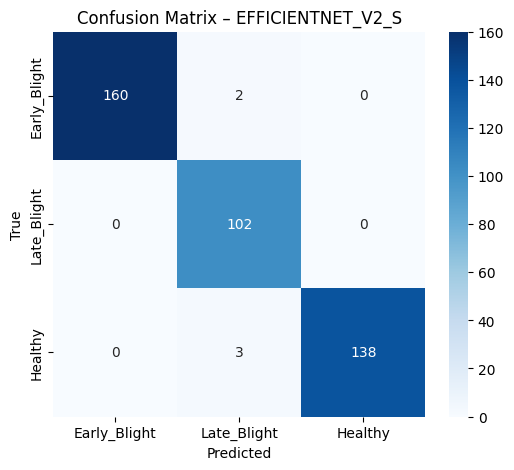

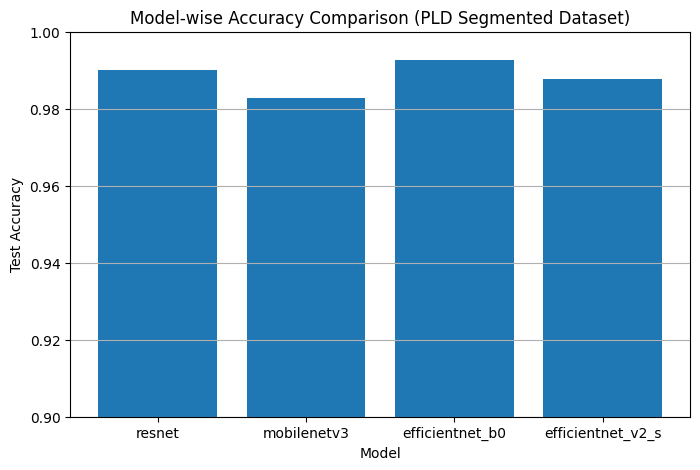


Final Test Accuracies:
RESNET                   : 0.9901
MOBILENETV3              : 0.9827
EFFICIENTNET_B0          : 0.9926
EFFICIENTNET_V2_S        : 0.9877


In [5]:
# =====================================================
# 12. FINAL EVALUATION: REPORTS + GRAPHS
# =====================================================
from sklearn.metrics import accuracy_score

all_accuracies = {}

for model_name, model in trained_models.items():
    print(f"\n================ {model_name.upper()} =================")

    y_true, y_pred = get_predictions(model, test_loader)

    acc = accuracy_score(y_true, y_pred)
    all_accuracies[model_name] = acc

    # ---------- Classification Report ----------
    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4
    ))

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"Confusion Matrix – {model_name.upper()}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# =====================================================
# 13. ACCURACY COMPARISON GRAPH
# =====================================================
plt.figure(figsize=(8,5))
plt.bar(
    all_accuracies.keys(),
    all_accuracies.values()
)
plt.ylabel("Test Accuracy")
plt.xlabel("Model")
plt.title("Model-wise Accuracy Comparison (PLD Segmented Dataset)")
plt.ylim(0.90, 1.00)
plt.grid(axis="y")
plt.show()

# =====================================================
# 14. PRINT ACCURACY TABLE (PAPER READY)
# =====================================================
print("\nFinal Test Accuracies:")
for k, v in all_accuracies.items():
    print(f"{k.upper():25s}: {v:.4f}")


In [ ]:
# =====================================================
# FAILURE CASE ANALYSIS – EfficientNet-B0 (SINGLE CELL)
# =====================================================
import torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# ------------------------------
# Get trained EfficientNet-B0
# ------------------------------
model = trained_models["efficientnet_b0"]
model.eval()

MAX_FAILURES = 10
failures = []

# ------------------------------
# Collect failure cases
# ------------------------------
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):
            if preds[i].item() != labels[i].item():
                failures.append({
                    "image": images[i].cpu(),
                    "true": CLASS_NAMES[labels[i].item()],
                    "pred": CLASS_NAMES[preds[i].item()]
                })

            if len(failures) >= MAX_FAILURES:
                break
        if len(failures) >= MAX_FAILURES:
            break

print(f"Total failure cases displayed: {len(failures)}")

# ------------------------------
# Visualize failure cases
# ------------------------------
plt.figure(figsize=(15, 5))

for idx, case in enumerate(failures):
    img = case["image"]

    # De-normalize
    img = TF.normalize(
        img,
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    plt.subplot(1, len(failures), idx + 1)
    plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
    plt.axis("off")
    plt.title(f"GT: {case['true']}\nPred: {case['pred']}")

plt.suptitle("Failure Cases – EfficientNet-B0 (PLD Segmented Dataset)", fontsize=14)
plt.show()


In [7]:
# =====================================================
# FINAL ERROR-FREE CODE
# Potato Leaf Disease | EfficientNetB0 | Grad-CAM
# Kaggle | Single Cell | Paper Ready
# =====================================================

import os, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

tf.random.set_seed(42)
np.random.seed(42)

# -----------------------------
# DATASET PATHS
# -----------------------------
BASE_DIR = "/kaggle/working/PLD_segmented"
TRAIN_DIR = os.path.join(BASE_DIR, "Training")
VAL_DIR   = os.path.join(BASE_DIR, "Validation")
TEST_DIR  = os.path.join(BASE_DIR, "Testing")

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

# -----------------------------
# LOAD DATASETS
# -----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y:(preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x,y:(preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x,y:(preprocess_input(x), y)).prefetch(AUTOTUNE)

# -----------------------------
# MODEL
# -----------------------------
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
conv_output = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(conv_output)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# -----------------------------
# GRAD-CAM MODEL
# -----------------------------
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[conv_output, model.output]
)

# -----------------------------
# GRAD-CAM FUNCTION
# -----------------------------
def generate_gradcam(img_array, class_idx=None):
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        if class_idx is None:
            class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy(), preds[0].numpy()

# -----------------------------
# SAVE FIGURE
# -----------------------------
os.makedirs("gradcam_results", exist_ok=True)

def save_paper_gradcam(img, heatmap, pred, true_label, idx):
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(heatmap_color); plt.title("Grad-CAM"); plt.axis("off")
    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title(f"True: {true_label}\nPred: {class_names[np.argmax(pred)]}")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"gradcam_results/sample_{idx}.png", dpi=300)
    plt.close()

# -----------------------------
# RUN GRAD-CAM
# -----------------------------
print("Generating paper-ready Grad-CAM figures...")

for i, (img_batch, label_batch) in enumerate(test_ds.take(5)):
    img_pre = img_batch[0].numpy()
    img_array = np.expand_dims(img_pre, axis=0)

    img_display = np.clip(img_pre, 0, 255).astype(np.uint8)
    true_label = class_names[label_batch[0]]

    heatmap, pred = generate_gradcam(img_array)
    save_paper_gradcam(img_display, heatmap, pred, true_label, i)

print("✓ Grad-CAM images saved in ./gradcam_results/")


Found 3251 files belonging to 3 classes.
Found 416 files belonging to 3 classes.
Found 405 files belonging to 3 classes.
Classes: ['Early_Blight', 'Healthy', 'Late_Blight']
Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 200ms/step - accuracy: 0.5211 - loss: 1.2114 - val_accuracy: 0.8438 - val_loss: 0.5529
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8073 - loss: 0.4921 - val_accuracy: 0.8966 - val_loss: 0.3570
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8665 - loss: 0.3505 - val_accuracy: 0.9087 - val_loss: 0.2616
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8845 - loss: 0.2937 - val_accuracy: 0.9087 - val_loss: 0.2219
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8901 - loss: 0.2801 - val_accuracy: 0.9159 - val_loss: 0.2015
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9098 - loss: 0.2356 - val_accuracy: 0.9231 - val_loss: 0.1894
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/ste

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_973']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


✓ Grad-CAM images saved in ./gradcam_results/
